# Notebook for practical exercises | Week #2 Lesson #2

## Introduction

This notebook contains practical hands-on exercises for the lesson about *Data visualization*.

After this session, you will know how to visualize and interprete a medical imaging dataset for training an AI model. We will implement and dissect four dimension reduction techniques which enables to better understand the data: 
- Principal Component Analysis (PCA)
- t-distributed Stochastic Neighbor Embedding (t-SNE)
- Uniform Manifold Approximation and Projection (UMAP)
- Linear Discriminant Analysis (LDA) 

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE

## Dataset

We will re-use the features extracted at lesson #1. If you did not succeed in extracting these features, we provide you with a back-up [HERE]. 

<div class="alert alert-block alert-info">
<b>Q1.</b> Load the standardized radiomic features in variable named <b>features</b>. Remove the columns containing the patient ID and the tumor label. Store the tumor label column in another variable named <b>labels</b>.
</div>

In [5]:
df = pd.read_csv('./radiomics_standardized.csv')
features = df.drop(['patient', 'tumor'], axis=1)
labels = df['tumor']

In [6]:
features.head()

,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,0.859229,1.067034,0.797794,-0.403429,-0.065381,-0.272373,-0.090654,-0.412250,0.118658,0.172015,...,-0.256520,-0.204795,-0.462470,-0.822257,-0.095128,-0.081902,-0.195262,-0.148660,-0.713150,-0.208590
1,0.895260,0.592973,0.384173,-0.410317,-0.353053,-0.246853,0.025922,-0.421685,-0.035678,0.178418,...,-0.283064,0.430202,-0.220422,-0.790855,-0.114257,-0.040694,-0.184531,-0.151587,-0.651935,-0.347854
2,-0.042169,0.201090,-0.237234,-0.582293,-0.607507,-0.621925,-0.781809,-0.640177,-0.631624,-0.737961,...,-0.111014,-0.427077,0.776127,-0.417649,-0.128351,-0.271384,-0.197609,-0.141318,-0.536644,-0.324345
3,1.228647,1.245570,-0.768837,-1.104782,-1.082911,-1.183949,-1.435860,-1.177182,-0.960833,-1.396755,...,-0.257207,-0.291498,-0.658263,-0.164278,-0.133651,-0.305896,-0.025903,-0.151176,-0.452287,-0.199718
4,-0.152393,-0.572770,-0.142303,-0.017470,0.024997,0.207070,0.552334,-0.032896,-0.176784,0.235367,...,0.007254,-0.552812,1.274900,0.388209,-0.134025,-0.296132,-0.202788,-0.007830,-0.558924,0.239030


## I. Principal Component Analysis (PCA) 

The goal of the PCA is to find the directions (also called *"principal components"*) where the **data vary the most**.
- **Unsupervised**: does not use nor require class labels ;
- **Linear**: each principal component is a weighted combination of original features, orthogonal to others.

### How does it work? 

1. Computes the covariance matrix of the data.
2. Finds eigenvectors (directions) and eigenvalues (amount of variance explained).
3. Projects the data onto the top-k components that explain the most variance.

### Pros/Cons 

- Interest for variance rather than class separability ;
- Linear projection for modeling or pre-processing (can be used as feature extractor) ;
- Not useful if data is nonlinear or clusters overlap along directions of high variance.

### Implementation 

We will start by computing the PCA with `n_components=2`, which means that we only want to compute the top-2 components that explain the most variance. 

<div class="alert alert-block alert-info">
<b>Q2.</b> Visualize the results with the scatterplot. What can you say about the amount of variance between data? 
</div>

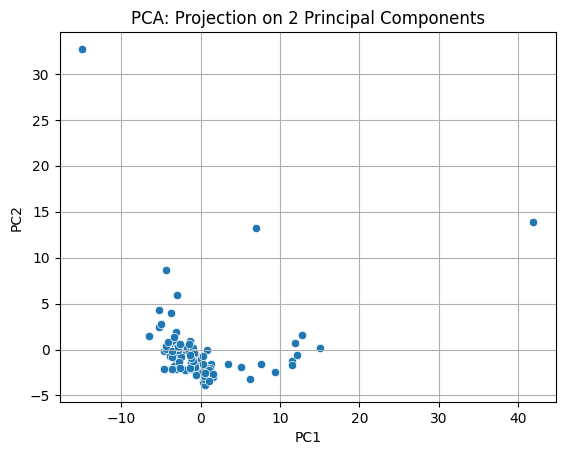

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1])
plt.title("PCA: Projection on 2 Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

You can label the points for better interpretability using the `hue` argument of the `scatterplot` function. 

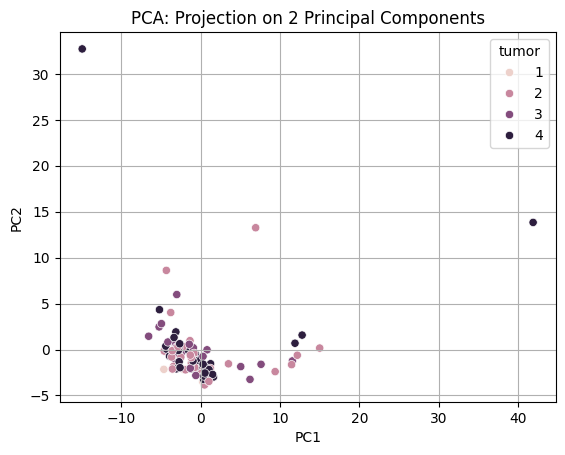

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels)
plt.title("PCA: Projection on 2 Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

### Quantitative values

Besides plotting the components, you can also have a look at the values of the PCA. 

First, you can look at the **explained variance ratio**, which tells you how much of the total variance is captured by each principal component.

In [18]:
# Explained variance per component
explained_var = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_var)

Explained variance ratio: [0.38289303 0.18844557]


You can also look at the **feature loadings**. These show how much each original feature contributes to each principal component. 

In [23]:
# Get the loadings
loadings = pd.DataFrame(
    pca.components_.T,  # Transpose so rows are features
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=features.columns
)

In [36]:
# Show top contributing features for PC1
loadings['PC1'].sort_values(key=abs, ascending=False).head(10)

original_firstorder_90Percentile             0.150659
original_firstorder_RootMeanSquared          0.148548
original_firstorder_Maximum                  0.146920
original_firstorder_Range                    0.146769
original_glcm_JointAverage                   0.146443
original_glcm_SumAverage                     0.146443
original_firstorder_Mean                     0.146072
original_glcm_DifferenceAverage              0.145727
original_glcm_Contrast                       0.141516
original_firstorder_MeanAbsoluteDeviation    0.141204
Name: PC1, dtype: float64

In [35]:
# Show worst contributing features for PC1
loadings['PC1'].sort_values(key=abs, ascending=True).head(10)

original_glcm_Idmn                        0.000101
original_firstorder_Skewness              0.002998
original_shape_LeastAxisLength            0.007516
original_shape_MajorAxisLength            0.008690
original_shape_Maximum2DDiameterColumn    0.008943
original_glcm_Idn                        -0.009295
original_shape_Maximum3DDiameter          0.012450
original_shape_Sphericity                -0.012769
original_firstorder_Kurtosis             -0.012938
original_ngtdm_Coarseness                -0.014774
Name: PC1, dtype: float64

<div class="alert alert-block alert-info">
<b>Q3.</b> Analyse the results and answer the following questions: 
    <br>
    - Are the features linearly separable?
    <br>
    - Does the tumor grade explain the largest amount of variance? 
    <br>
    - Does the shape of the tumor does contribute to a large amount of variance?
</div>

## II. T-distributed Stochastic Neighbor Embedding (t-SNE)

t-SNE emphasizes local structure by keeping similar points close. This technique is highly useful for exploring clusters.
- **Nonlinear**
- **Unsupervised**

### How does it work?
1. Converts pairwise distances into probabilities that measure similarity ;
2. Tries to minimize the difference between high- and low-dimensional similarities ;
3. Uses perplexity as a smoothing parameter (number of neighbors).

### Pros/Cons
- Results cannot be interpreted quantitatively (distances are not reliable) ;
- Sensitive to perplexity and random seed — unstable with noise or outliers ;
- Useful for data exploration, not for data modelling.

### Implementation

In [38]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(features)

<div class="alert alert-block alert-info">
<b>Q4.</b> Plot the results, similarly to what we have done for the PCA and explore similarity across tumor grades.
</div>

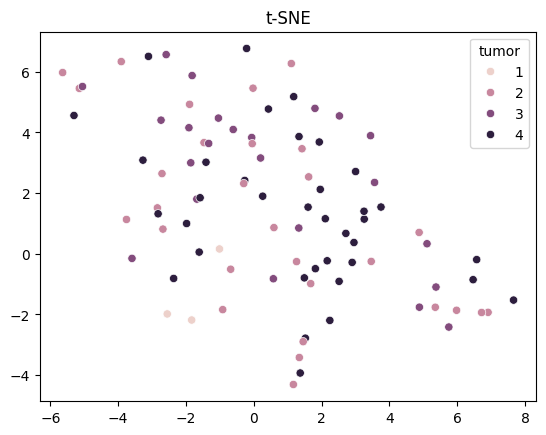

In [41]:
sns.scatterplot(...) # COMPLETE
plt.title(...) # COMPLETE
plt.grid(...) # COMPLETE
plt.show()

<div class="alert alert-block alert-info">
<b>Q5.</b> Modify the parameters of the tSNE (perplexity, random state) and compare the results. Discuss the reproducibility and sensitivity of the algorighm.
</div>

## III. Uniform Manifold Approximation and Projection (UMAP)

UMAP balances local and global structure in data. It constructs a high dimensional graph representation of the data then optimizes a low-dimensional graph to be as structurally similar as possible. 
- **Nonlinear**
- **Unsupervised**

Have a look at this interactive website about the difference between UMAP and tSNE:
[https://pair-code.github.io/understanding-umap/](https://pair-code.github.io/understanding-umap/). 

In [ ]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(features)

sns.scatterplot(x=X_umap[:,0], y=X_umap[:,1], hue=labels)
plt.title("UMAP: Preserving Local and Global Patterns")
plt.grid(True)
plt.show()

<div class="alert alert-block alert-info">
<b>Q6.</b> Visualize the features color-coded by tumor grade. Compare with the previous visualization and hypothesize on the variance and separability of features. 
</div>

## IV. Linear Discriminant Analysis (LDA)

LDA finds directions that best separate known classes.
- **Supervised**: uses label Y to find discriminant axes
- **Linear**

### How does it work?
1. Calculates between-class and within-class scatter ;
2. Maximizes the ratio of between-class to within-class variance ;
3. Finds axes (discriminants) that maximize class separation.

### Pros/Cons
- Requires to have access to class labels.
- If the data have too many classes vs. too few samples, LDA can overfit.
- Nonlinear class separation — LDA can miss curved or nested boundaries.
- Classes must be reasonably normally distributed with equal covariance.

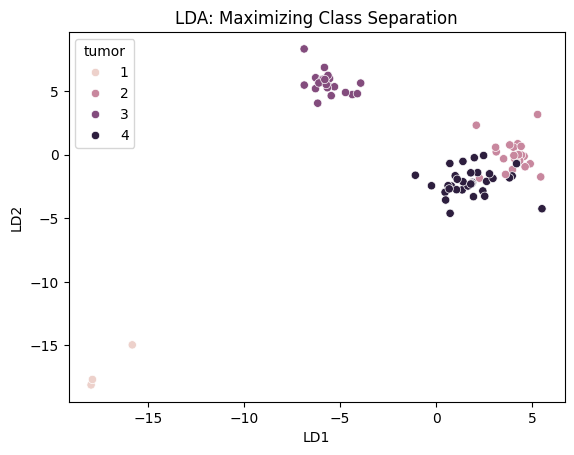

In [58]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(features, labels)

sns.scatterplot(x=X_lda[:,0], y=X_lda[:,1], hue=labels)
plt.title("LDA: Maximizing Class Separation")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(False)
plt.show()

Similar to PCA, we can explore quantitative parameters of the LDA.

Each linear discriminant (LD1, LD2, etc.) represents a direction that separates the classes. You can check how much class separation each one contributes. Explained variance ratio, in that case, will tell you how much of the total class-discriminating power is captured by each axis.

<div class="alert alert-block alert-info">
<b>Q7.</b> Print the <b>explained variance ratio</b> of the LDA. How does it compare to the one obtained with PCA?
</div>

In [59]:
# Explained variance ratio
print(lda.explained_variance_ratio_)

[0.47654374 0.3796726 ]


<div class="alert alert-block alert-info">
<b>Q8.</b> Using the code below, complete and visualize the most important features to separate classes. These are stored in the attribute <b>coef_</b>. <br>
Compare with the ones obtained with PCA.
</div>

In [ ]:
# Get the loadings
coefficients = pd.DataFrame(
    lda...,  # COMPLETE - Transpose so rows are features
    columns=[f'LD{i+1}' for i in range(len(lda...))], # COMPLETE - Get numbers of LD 
    index=features.columns
)

In [56]:
coefficients['LD1'].sort_values(key=abs, ascending=False).head(10)

original_firstorder_Entropy                       -3565.779727
original_firstorder_Uniformity                     2927.224206
original_glrlm_GrayLevelNonUniformityNormalized   -2768.262384
original_glszm_GrayLevelVariance                   2433.351859
original_gldm_DependenceEntropy                    2399.057213
original_glcm_JointEnergy                         -2344.893026
original_glrlm_RunPercentage                       2278.724847
original_glcm_SumEntropy                           1991.144501
original_firstorder_90Percentile                   1863.776518
original_glszm_ZonePercentage                      1718.676072
Name: LD1, dtype: float64

<div class="alert alert-block alert-info">
<b>Q9.</b> Overall, which visualization strategy gave you the largest amount of information on the dataset? What can you conclude?
</div>

## V. Out-of-sample mapping

Dimension reduction strategies are particularly useful to visualize clusters / groups of points in the dataset. When a new sample comes out, we can also use these techniques to compare this sample to the others: *e.g.*, if this sample is close to other samples from a particular class, we can suppose that it belongs to this class.

<div class="alert alert-block alert-info">
<b>Q10.</b> Given the features of a new sample below, use the <b>transform</b> function from the <b>lda</b> variable to compute the values of the linear discriminants for this sample. Add this sample to the previous plot and hypothesize on the class of this new sample.
</div>

In [91]:
new_sample = [[ 0.8980526 ,  0.59569199,  0.39275908, -0.40053663, -0.34329607,
        -0.23977779,  0.02661877, -0.41738692, -0.03277963,  0.18529005,
         0.84592692, -0.27865205, -0.66556575, -0.03254253, -0.48758848,
        -0.58253994, -0.17182531, -0.51072641, -0.58392225,  0.05179291,
        -0.40100902, -0.5645289 , -0.56450294, -0.55107502, -0.58575912,
        -0.38506113, -0.59142683, -0.57781549,  0.57503623, -0.19220908,
        -0.02812181, -0.32770358, -0.28670191, -0.13094835, -0.13530316,
        -0.32722358, -0.32356057,  0.06153568, -0.59688055, -0.74346848,
        -0.29190261,  0.78537542,  0.82547277,  0.54787038,  0.66506214,
        -0.54165784,  0.32372496,  0.89320514, -0.5294179 , -0.14439517,
        -0.56105997,  0.0802503 , -0.1364634 , -0.52569267, -0.45794935,
        -0.32712368,  0.31293392, -0.38569349, -0.81228518,  0.49376176,
        -0.16553029, -0.32365436, -0.28320423,  0.39544275, -0.44054332,
        -0.22405002, -0.20295807, -0.78577507, -0.23484142, -0.01029493,
        -0.03790843,  0.12000761, -0.32057798, -0.29126663, -0.10039401,
        -0.30769981, -0.13244548, -0.1114434 , -0.29087715, -0.36883834,
        -0.93563645, -0.67985549, -0.12046937, -0.75872192, -0.28225195,
         0.04846077, -0.42501974, -0.01650915, -0.30365008, -0.30066516,
        -0.10727354, -0.28977265, -0.10269839,  0.41017304, -0.31533614,
        -0.41009884, -0.28803977, -0.2757545 ,  0.43914615, -0.21142525,
        -0.78169884, -0.11001161, -0.03714914, -0.17941309, -0.14652707,
        -0.65065644, -0.33900533]]

In [92]:
X_new_lda = lda... # COMPLETE lda.transform(new_sample)

/Users/egermani/miniforge3/envs/aim-course/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearDiscriminantAnalysis was fitted with feature names
  warnings.warn(


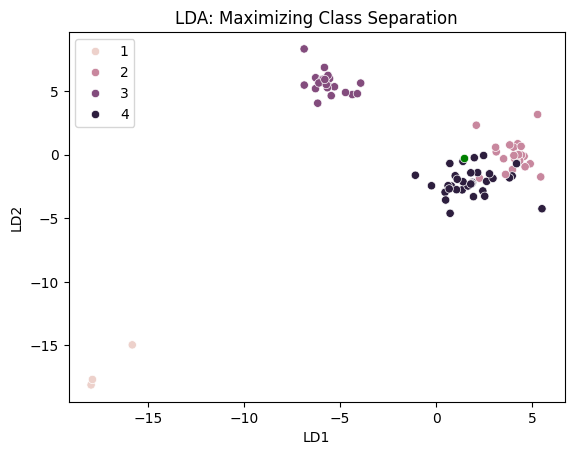

In [95]:
sns.scatterplot(..., hue=labels)
sns.scatterplot(..., color='green')
plt.title("LDA: Maximizing Class Separation")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.grid(False)
plt.show()